Step 1: Load Dataset

In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Superstore.csv', encoding='latin1')
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31-12-2014,04-01-2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,05-01-2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,02-01-2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,06-01-2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


Check datatypes

In [312]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


Step 2: Data Cleaning

In [313]:

df.drop(['customer_name', 'product_name','order_id','product_id'], axis=1, inplace=True)


df['sales'] = df['sales'].str.replace(',', '')
df['sales'] = df['sales'].astype(float)

df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)
df


,order_date,ship_date,ship_mode,segment,state,country,market,region,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,2011-01-01,2011-01-06,Standard Class,Consumer,Constantine,Algeria,Africa,Africa,Office Supplies,Storage,408.0,2,0.0,106.1400,35.46,Medium,2011
1,2011-01-01,2011-01-08,Standard Class,Consumer,New South Wales,Australia,APAC,Oceania,Office Supplies,Supplies,120.0,3,0.1,36.0360,9.72,Medium,2011
2,2011-01-01,2011-01-05,Second Class,Consumer,Budapest,Hungary,EMEA,EMEA,Office Supplies,Storage,66.0,4,0.0,29.6400,8.17,High,2011
3,2011-01-01,2011-01-05,Second Class,Home Office,Stockholm,Sweden,EU,North,Office Supplies,Paper,45.0,3,0.5,-26.0550,4.82,High,2011
4,2011-01-01,2011-01-08,Standard Class,Consumer,New South Wales,Australia,APAC,Oceania,Furniture,Furnishings,114.0,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-12-31,2015-01-04,Standard Class,Corporate,California,United States,US,West,Office Supplies,Binders,14.0,2,0.2,4.5188,0.89,Medium,2014
51286,2014-12-31,2015-01-05,Standard Class,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,Office Supplies,Binders,4.0,1,0.0,0.4200,0.49,Medium,2014
51287,2014-12-31,2015-01-02,Second Class,Consumer,Managua,Nicaragua,LATAM,Central,Office Supplies,Labels,26.0,3,0.0,12.3600,0.35,Medium,2014
51288,2014-12-31,2015-01-06,Standard Class,Consumer,Chihuahua,Mexico,LATAM,North,Office Supplies,Labels,7.0,1,0.0,0.5600,0.20,Medium,2014


Step 3: Handle Missing Data

In [314]:
df = df.fillna(0)
df


,order_date,ship_date,ship_mode,segment,state,country,market,region,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,2011-01-01,2011-01-06,Standard Class,Consumer,Constantine,Algeria,Africa,Africa,Office Supplies,Storage,408.0,2,0.0,106.1400,35.46,Medium,2011
1,2011-01-01,2011-01-08,Standard Class,Consumer,New South Wales,Australia,APAC,Oceania,Office Supplies,Supplies,120.0,3,0.1,36.0360,9.72,Medium,2011
2,2011-01-01,2011-01-05,Second Class,Consumer,Budapest,Hungary,EMEA,EMEA,Office Supplies,Storage,66.0,4,0.0,29.6400,8.17,High,2011
3,2011-01-01,2011-01-05,Second Class,Home Office,Stockholm,Sweden,EU,North,Office Supplies,Paper,45.0,3,0.5,-26.0550,4.82,High,2011
4,2011-01-01,2011-01-08,Standard Class,Consumer,New South Wales,Australia,APAC,Oceania,Furniture,Furnishings,114.0,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-12-31,2015-01-04,Standard Class,Corporate,California,United States,US,West,Office Supplies,Binders,14.0,2,0.2,4.5188,0.89,Medium,2014
51286,2014-12-31,2015-01-05,Standard Class,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,Office Supplies,Binders,4.0,1,0.0,0.4200,0.49,Medium,2014
51287,2014-12-31,2015-01-02,Second Class,Consumer,Managua,Nicaragua,LATAM,Central,Office Supplies,Labels,26.0,3,0.0,12.3600,0.35,Medium,2014
51288,2014-12-31,2015-01-06,Standard Class,Consumer,Chihuahua,Mexico,LATAM,North,Office Supplies,Labels,7.0,1,0.0,0.5600,0.20,Medium,2014


Step 4: Keep Original Dataset

In [315]:
df_original = df.copy()

Step 5: Outlier Detection & Removal

In [316]:
Q1 = df[['sales','profit','quantity','discount','shipping_cost']].quantile(0.25)
Q3 = df[['sales','profit','quantity','discount','shipping_cost']].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[['sales','profit','quantity','discount','shipping_cost']] < (Q1 - 1.5 * IQR)) |
                (df[['sales','profit','quantity','discount','shipping_cost']] > (Q3 + 1.5 * IQR))).any(axis=1)]
df_clean


,order_date,ship_date,ship_mode,segment,state,country,market,region,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year
1,2011-01-01,2011-01-08,Standard Class,Consumer,New South Wales,Australia,APAC,Oceania,Office Supplies,Supplies,120.0,3,0.1,36.0360,9.72,Medium,2011
2,2011-01-01,2011-01-05,Second Class,Consumer,Budapest,Hungary,EMEA,EMEA,Office Supplies,Storage,66.0,4,0.0,29.6400,8.17,High,2011
3,2011-01-01,2011-01-05,Second Class,Home Office,Stockholm,Sweden,EU,North,Office Supplies,Paper,45.0,3,0.5,-26.0550,4.82,High,2011
4,2011-01-01,2011-01-08,Standard Class,Consumer,New South Wales,Australia,APAC,Oceania,Furniture,Furnishings,114.0,5,0.1,37.7700,4.70,Medium,2011
5,2011-01-01,2011-01-08,Standard Class,Consumer,New South Wales,Australia,APAC,Oceania,Office Supplies,Paper,55.0,2,0.1,15.3420,1.80,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-12-31,2015-01-04,Standard Class,Corporate,California,United States,US,West,Office Supplies,Binders,14.0,2,0.2,4.5188,0.89,Medium,2014
51286,2014-12-31,2015-01-05,Standard Class,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,Office Supplies,Binders,4.0,1,0.0,0.4200,0.49,Medium,2014
51287,2014-12-31,2015-01-02,Second Class,Consumer,Managua,Nicaragua,LATAM,Central,Office Supplies,Labels,26.0,3,0.0,12.3600,0.35,Medium,2014
51288,2014-12-31,2015-01-06,Standard Class,Consumer,Chihuahua,Mexico,LATAM,North,Office Supplies,Labels,7.0,1,0.0,0.5600,0.20,Medium,2014


Step 5: Compare Both Datasets

In [317]:
print("Original Shape:", df_original.shape)
print("Cleaned Shape:", df_clean.shape)

removed = df_original.shape[0] - df_clean.shape[0]
print("Rows Removed:", removed)

Original Shape: (51290, 17)
Cleaned Shape: (36311, 17)
Rows Removed: 14979


Step 6: Visual Comparison

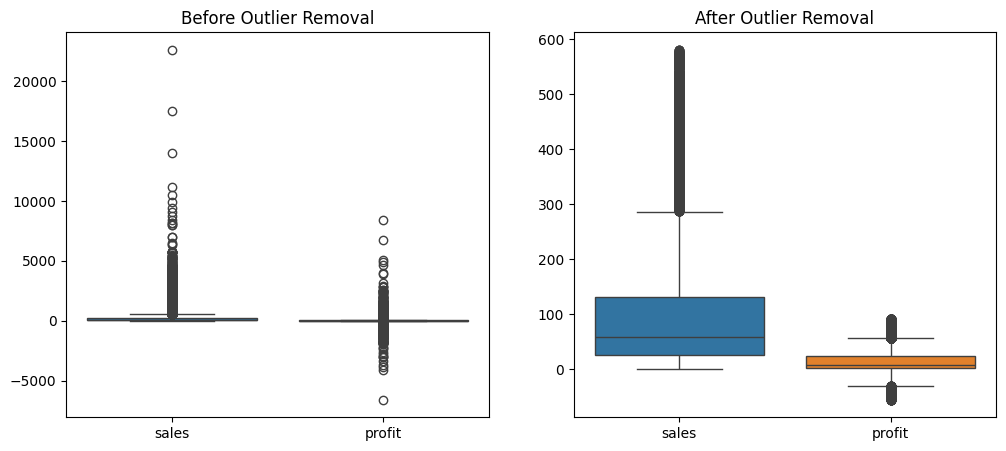

In [318]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=df_original[['sales','profit']])
plt.title("Before Outlier Removal")

plt.subplot(1,2,2)
sns.boxplot(data=df_clean[['sales','profit']])
plt.title("After Outlier Removal")

plt.show()

STEP 7: Feature Scaling

In [325]:
numeric_cols = ['sales','profit','quantity','discount','shipping_cost']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale and assign safely
df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols].astype(float))
df_clean

,order_date,ship_date,ship_mode,state,country,market,sales,quantity,discount,profit,...,region_Central,region_Central Asia,region_EMEA,region_East,region_North,region_North Asia,region_Oceania,region_South,region_Southeast Asia,region_West
1,2011-01-01,2011-01-08,Standard Class,New South Wales,Australia,APAC,0.235193,-0.056329,0.056412,0.920006,...,0,0,0,0,0,0,1,0,0,0
2,2011-01-01,2011-01-05,Second Class,Budapest,Hungary,EMEA,-0.303216,0.476737,-0.616938,0.648778,...,0,0,1,0,0,0,0,0,0,0
3,2011-01-01,2011-01-05,Second Class,Stockholm,Sweden,EU,-0.512596,-0.056329,2.749813,-1.713019,...,0,0,0,0,1,0,0,0,0,0
4,2011-01-01,2011-01-08,Standard Class,New South Wales,Australia,APAC,0.175370,1.009804,0.056412,0.993538,...,0,0,0,0,0,0,1,0,0,0
5,2011-01-01,2011-01-08,Standard Class,New South Wales,Australia,APAC,-0.412891,-0.589396,0.056412,0.042458,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-12-31,2015-01-04,Standard Class,California,United States,US,-0.821683,-0.589396,0.729762,-0.416509,...,0,0,0,0,0,0,0,0,0,1
51286,2014-12-31,2015-01-05,Standard Class,Souss-Massa-Draâ,Morocco,Africa,-0.921388,-1.122463,-0.616938,-0.590323,...,0,0,0,0,0,0,0,0,0,0
51287,2014-12-31,2015-01-02,Second Class,Managua,Nicaragua,LATAM,-0.702036,-0.056329,-0.616938,-0.083996,...,1,0,0,0,0,0,0,0,0,0
51288,2014-12-31,2015-01-06,Standard Class,Chihuahua,Mexico,LATAM,-0.891476,-1.122463,-0.616938,-0.584386,...,0,0,0,0,1,0,0,0,0,0


In [320]:
df_clean[['sales','profit','quantity','discount','shipping_cost']].describe()


,sales,profit,quantity,discount,shipping_cost
count,3.631100e+04,3.631100e+04,3.631100e+04,3.631100e+04,3.631100e+04
mean,2.367758e-17,-4.344152e-17,-7.396799e-17,2.974374e-17,7.284281e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-9.512995e-01,-2.945759e+00,-1.122463e+00,-6.169379e-01,-8.911092e-01
25%,-6.920659e-01,-5.241694e-01,-5.893962e-01,-6.169379e-01,-6.836349e-01
50%,-3.730092e-01,-2.353852e-01,-5.632941e-02,-6.169379e-01,-3.789653e-01
75%,3.448684e-01,4.007034e-01,4.767374e-01,7.297624e-01,2.911207e-01
max,4.831603e+00,3.293015e+00,3.142071e+00,2.749813e+00,4.454626e+00


 Encoding Categorical Columns

In [321]:
df_clean = pd.get_dummies(df_clean,  columns=['segment','category','sub_category','region'],drop_first=True,dtype=int)
df_clean

,order_date,ship_date,ship_mode,state,country,market,sales,quantity,discount,profit,...,region_Central,region_Central Asia,region_EMEA,region_East,region_North,region_North Asia,region_Oceania,region_South,region_Southeast Asia,region_West
1,2011-01-01,2011-01-08,Standard Class,New South Wales,Australia,APAC,0.235193,-0.056329,0.056412,0.920006,...,0,0,0,0,0,0,1,0,0,0
2,2011-01-01,2011-01-05,Second Class,Budapest,Hungary,EMEA,-0.303216,0.476737,-0.616938,0.648778,...,0,0,1,0,0,0,0,0,0,0
3,2011-01-01,2011-01-05,Second Class,Stockholm,Sweden,EU,-0.512596,-0.056329,2.749813,-1.713019,...,0,0,0,0,1,0,0,0,0,0
4,2011-01-01,2011-01-08,Standard Class,New South Wales,Australia,APAC,0.175370,1.009804,0.056412,0.993538,...,0,0,0,0,0,0,1,0,0,0
5,2011-01-01,2011-01-08,Standard Class,New South Wales,Australia,APAC,-0.412891,-0.589396,0.056412,0.042458,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-12-31,2015-01-04,Standard Class,California,United States,US,-0.821683,-0.589396,0.729762,-0.416509,...,0,0,0,0,0,0,0,0,0,1
51286,2014-12-31,2015-01-05,Standard Class,Souss-Massa-Draâ,Morocco,Africa,-0.921388,-1.122463,-0.616938,-0.590323,...,0,0,0,0,0,0,0,0,0,0
51287,2014-12-31,2015-01-02,Second Class,Managua,Nicaragua,LATAM,-0.702036,-0.056329,-0.616938,-0.083996,...,1,0,0,0,0,0,0,0,0,0
51288,2014-12-31,2015-01-06,Standard Class,Chihuahua,Mexico,LATAM,-0.891476,-1.122463,-0.616938,-0.584386,...,0,0,0,0,1,0,0,0,0,0


Step 8: Analysis

In [322]:
# Total
print("Total Sales:", df_clean['sales'].sum())
print("Total Profit:", df_clean['profit'].sum())


Total Sales: 8.597567102697212e-13
Total Profit: -1.5774048733874224e-12


Step 9: Export Clean Data

In [323]:
df_clean.to_csv('Superstore_Cleaned.csv', index=False)
df_clean

,order_date,ship_date,ship_mode,state,country,market,sales,quantity,discount,profit,...,region_Central,region_Central Asia,region_EMEA,region_East,region_North,region_North Asia,region_Oceania,region_South,region_Southeast Asia,region_West
1,2011-01-01,2011-01-08,Standard Class,New South Wales,Australia,APAC,0.235193,-0.056329,0.056412,0.920006,...,0,0,0,0,0,0,1,0,0,0
2,2011-01-01,2011-01-05,Second Class,Budapest,Hungary,EMEA,-0.303216,0.476737,-0.616938,0.648778,...,0,0,1,0,0,0,0,0,0,0
3,2011-01-01,2011-01-05,Second Class,Stockholm,Sweden,EU,-0.512596,-0.056329,2.749813,-1.713019,...,0,0,0,0,1,0,0,0,0,0
4,2011-01-01,2011-01-08,Standard Class,New South Wales,Australia,APAC,0.175370,1.009804,0.056412,0.993538,...,0,0,0,0,0,0,1,0,0,0
5,2011-01-01,2011-01-08,Standard Class,New South Wales,Australia,APAC,-0.412891,-0.589396,0.056412,0.042458,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-12-31,2015-01-04,Standard Class,California,United States,US,-0.821683,-0.589396,0.729762,-0.416509,...,0,0,0,0,0,0,0,0,0,1
51286,2014-12-31,2015-01-05,Standard Class,Souss-Massa-Draâ,Morocco,Africa,-0.921388,-1.122463,-0.616938,-0.590323,...,0,0,0,0,0,0,0,0,0,0
51287,2014-12-31,2015-01-02,Second Class,Managua,Nicaragua,LATAM,-0.702036,-0.056329,-0.616938,-0.083996,...,1,0,0,0,0,0,0,0,0,0
51288,2014-12-31,2015-01-06,Standard Class,Chihuahua,Mexico,LATAM,-0.891476,-1.122463,-0.616938,-0.584386,...,0,0,0,0,1,0,0,0,0,0


In [324]:
from google.colab import files
files.download('Superstore_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>